In [5]:
import matplotlib.pyplot as plt
import numpy as np

### Skewing the temperature

It took me a long time to figure out that we need to use the temperature skew function as a final step before plotting. I started working with the isotherms as a background check to know I was implementing the function properly. Once I got that, I applied on my plot block after obtaining each "family" of lines thet were T-dependent

In [6]:
def skewT(temp, pres, skew=-20):
    """Skews the temperature axis for a SkewT plot.
temp: temperature values (deg C)
pres: pressure values (hPa)
skew: amount of skew (default of -20)"""

    return (temp) + skew * np.log(pres/1000.0)

### Constants definition
Just as a reminder, super important to clarify the units. I always try to work using IS and, if not, I make explicit what alternative I use. Before approaching the lab, I wanted to pay special attention to not confusing Celsius with Kelvin and to account for the use of hPa instead of Pa when necessary.

In [7]:
# Definition of the necessary constants:
R_d = 287 # J / kg·K
R_v = 461 # J / kg·K
c_pd = 1004 # J / kg·K
L_v = 2.5e6 # J / kg
eps = 0.622 # = R_d/R_v, Adimensional
g = 9.81 # m / s^2

### Dry adiabats
For the plotting of the dry adiabats I decided to use the potental temperature equation. The potential temperature is defined as the reference temperature when an air parcel is interacting with its environment through adiabatic processes (so, without exchanging heat). So, considering an inital temperature $T_0$ and an initial pressure $p_0=1000~hPa$, we can, using the expression $$\theta=T\left(\frac{p_0}{p}\right)^{R/c_p}$$ derive the corresponding adiabatic trajectories as we increase the pressure.

### Moist adiabats
#### Calculating the changes in T with p at every level

For the representation of the moist adiabats, and considering the following expressions: 
$$e_s(T)=6.112\cdot \exp{17.67\frac{T-273.15}{T-29.65}}$$
$$r_s(T, p)=\epsilon\cdot\frac{e_s(T)}{p-e_s(T)}$$
$$\epsilon=\frac{R_d}{R_v}\approx 0.622$$
$$\Gamma_m\equiv -\frac{dT}{dz}=\frac{g}{c_{pd}}\frac{1+\frac{L_vr_s}{R_dT}}{1+\frac{L_v^2r_s}{c_pdR_vT^2}}$$

And then changing the vertical coordinate from $z$ to $p$ via the implementation of the hydrostatic balance:
$$\frac{dT}{dp}=-\frac{1}{\rho g}\frac{dT}{dz}=\frac{g\alpha}{c_{pd}\rho g}=\frac{\alpha}{c_{pd}\rho}, ~~\alpha = \frac{1+\frac{L_vr_s}{R_dT}}{1+\frac{L_v^2r_s}{c_pdR_vT^2}}$$

We obtain an expression for the change in temperature with pressure followed in a moist adiabatic regime. This expression depends on the temperature $T$ and the pressure $p$ on each considered vertical level, so we can re-calculate the temperature evolution at every pressure-step considered:

$$\frac{dT}{dp}\approx\frac{\Delta T}{\Delta p}=\frac{T_f-T_i}{p_f-p_i}$$
$$T_f\approx T_i+ \frac{dT}{dp} \cdot (p_f-p_i)=T_i+ \frac{\alpha}{c_{pd}\rho} \cdot (p_f-p_i)$$
, And mind that $p_f-p_i<0$ because pressure decreases as we ascend from the surface.

In [8]:
# Definition of the initial functions:
    # Dry adiabats
def pot_T(T0, p, p0=1000):
    """Evolution of temperature following a dry adiabatic process. Returns 
    the final temperature in Celsius, ready to be skewwed and then plotted.
        T0: Initial temperature, Celsius
        p: environmental pressure, hPa
        p0: reference pressure, hPa"""
    T0_K = T0 + 273.15
    T_K = T0_K * (p / p0)**(R_d/c_pd)
    return T_K - 273.15

    # Moist Adiabats
def e_s(T):
    """This function returns hPa. Temperatures must be in K in return
        e_s(T): saturation vapour pressure, hPa
        T: temp. where I calculate the pressure, Celsius"""
    T_K = T + 273.15
    return (6.112 * np.exp(17.67 * ((T_K-273.15)/(T_K-29.65))))

def r_s(e_s, p):
    """Expression for the mixing ratio. Both pressures are in hPa.
    epsilon is adimensional and the return value is also adimensional.
        e_s: saturation vapour pressure, hPa
        p: environment pressure, hPa"""
    return (eps * ((e_s)/(p-e_s)))

def rho(T, p):
    """Calculates air density following the ideal gas law. Returns density in IS units.
        T: environment temperature, Celsius
        p: environment pressure, hPa"""
    return (p*100) / (R_d * (T+273.15))

def alpha(r_s, T):
    """alpha is adimensional, all of the parameters in the "return" must be 
    expressed using the IS.
        r_s: mixing ratio at the considered level, adimensional
        T: initial temperature at a given level, Celsius"""
    T_K = T + 273.15
    return ((1+(L_v * r_s)/(R_d * T_K))/(1 + (L_v**2 * r_s)/(c_pd * R_v * T_K**2)))

def dT_dp(alpha, rho):
    """The units of the differential are K(or C)/Pa (IS)
        alpha: adimensional
        rho: air density at a given vertical level, kg/m^3"""
    return (alpha / (c_pd * rho))

In [49]:
# Definition of the different arrays used for plotting:
pres_guides = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100] #Pressure lines for plot reference, hPa
pres = np.arange(1000, 99, -1) #Leaps of pressure for profiles every 1 hPa (100 Pa!!!)

temp_IT = np.arange(-80, 51, 10) #Isotherms, Celsius
temp_DA = np.arange(-40, 251, 10) #Dry Adiabats, Celsius
temp_MA = np.arange(-40, 251, 5) #Moist Adiabats, increase frequency for better visibility, Celsius

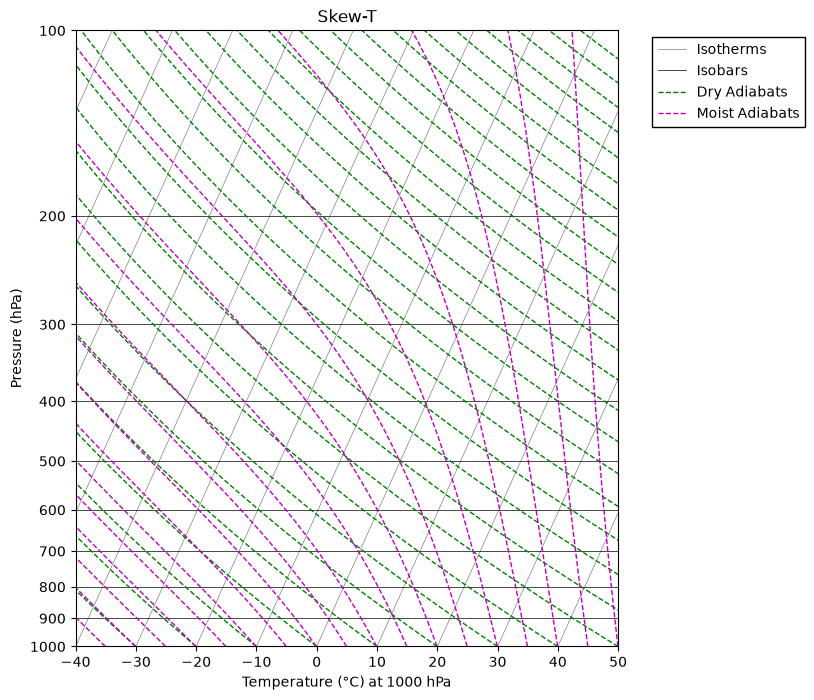

In [55]:
# Figure definition
fig, ax = plt.subplots(figsize=(7, 8))
ax.set_yscale("log") #Pressure in log (base 10) scale
ax.set_ylim(1000, 100) # In hPa
ax.set_xlim(-40, 50) # In Celsius

# Isotherms
i=0
label_IT=""
for T0 in temp_IT:
    if i==0:
        label_IT="Isotherms"
    else:
        label_IT="_"
    T_sk = skewT(T0, pres, skew=-20)

    ax.plot(
        T_sk, pres,
        color="grey",
        linewidth=0.5,
        label=label_IT
    )
    i+=1
# Isobars
i=0
label_IB=""
for p in pres_guides:
    if i==0:
        label_IB="Isobars"
    else:
        label_IB="_"

    ax.axhline(
        p,
        color="black",
        linewidth=0.5, 
        label=label_IB
    )
    i+=1

# Dry adiabats
i=0
label_DA=""
for T0 in temp_DA:
    if i==0:
        label_DA="Dry Adiabats"
    else:
        label_DA="_"

    # Temperature along the dry adiabat
    T = pot_T(T0, pres)

    # Transform into Skew-T coordinates
    T_sk = skewT(T, pres, skew=-20)

    ax.plot(
        T_sk, pres,
        color="green",
        linestyle="--",
        linewidth=1,
        label=label_DA
    )
    i+=1

# Moist adiabats
i=0
label_MA=""
for T0 in temp_MA:
    T_MA=[] # Array that will be filled with the moist-adiabat evolution of a parcel starting at T0, p0
    for p0 in pres:
        #alculating the variables for each (T,p) level
        e_s0=e_s(T0)
        r_s0=r_s(e_s0, p0)
        rho0=rho(T0, p0)
        alpha0=alpha(r_s0, T0)
        dT_dp0=dT_dp(alpha0, rho0)

        Tf = T0 + dT_dp0 * (-100) # increment of 1 hPa is 100 Pa. Negative because p decreases w height!!!
        T_MA = np.append(T_MA, Tf) # for every level, we append the corresponding evolution of T
        T0 = Tf # We initialize the temperature for the next iteration
    
    # Transform into Skew-T
    if i==0:
        label_MA="Moist Adiabats"
    else:
        label_MA="_"
    T_sk = skewT(T_MA, pres, skew=-20)
    ax.plot(
            T_sk, pres,
            linestyle="--",
            color="m",
            linewidth=1,
            label=label_MA
            )
    i+=1
    
# Saturtation vapour pressure
#temp_SVP = np.arange(-40, 51, 1)
#SVP = e_s(temp_SVP)
#T_sk = skewT(temp_SVP, SVP, skew=-20)
#ax.plot(temp_SVP, SVP, color=("black"))


    # Axis configuration
ax.set_yticks(pres_guides)
ax.set_yticklabels([str(p) for p in pres_guides]) # Use the same array as the isobars
ax.minorticks_off()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fancybox=False, framealpha=1, edgecolor="black")

ax.set_xlabel("Temperature (°C) at 1000 hPa")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Skew-T")

plt.show()

In [27]:
import pandas as pd
profile = pd.read_csv(r"C:\Users\celia\Documents\research\METR5003\00000086_thermo_profile.csv")

p_s = profile["pressure_hPa"].to_numpy()
# Temperatures are recorded in K, I need to remove the offset:
T_s = profile["temperature_C"].to_numpy() - 273.15
Td_s = profile["dewpoint_C"].to_numpy() - 273.15

## Incorporation of Sounding
For this lab, and given that I am working with the CopterSonde (CS) project, I asked for Dr. Tony Segales permission to use soundings from the drones. On the following cell I plotted a case from last Wednesday (09/30/2026).

I find this to be a wonderful coincidence because it rained quite heavily and that can be seen in the sounding. Before discussing some of the features of the profiles in more detail, I would like to comment briefly on the dataset.

#### Dataset variables:
- For the obtention of the vertical profiles, I extracted pressure $p$, altitude $z$, temperature $T$ and relative humidity $RH$.
- Using $z$, I only kept the ascent of the drone, so one can only see from takeoff to the apogee on the sounding.
- The CS has 3 sensors for each $T$ and $RH$. For both variables I calculated the mean and then derived the dew point temperature $T_d$ using the Magnus expression: $$T_d=\frac{b\gamma}{a-\gamma}, ~~\gamma=\ln(RH/100)+\frac{aT}{b+T}$$
- Then I saved the variables on the attached .csv file.

The interpretation of the sounding features is included in prompt 4 below. 


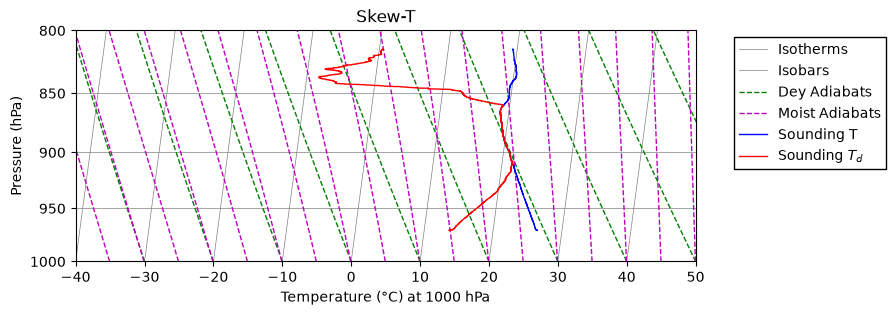

In [57]:
pres = np.arange(1000, 799, -1)
pres_guides=[1000, 950, 900, 850, 800]
skew_CS = -20
# Figure definition
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_yscale("log") #Pressure in log (base 10) scale
ax.set_ylim(1000, 800) # In hPa
ax.set_xlim(-40, 50) # In Celsius

# Isotherms
i=0
label_IT=""
for T0 in temp_IT:
    if i==0:
        label_IT="Isotherms"
    else:
        label_IT="_"

    T_sk = skewT(T0, pres, skew=skew_CS)

    ax.plot(
        T_sk, pres,
        color="grey",
        linewidth=0.5,
        label=label_IT
    )
    i+=1

# Isobars
i=0
label_IB=""
for p in pres_guides:
    if i==0:
        label_IB="Isobars"
    else:
        label_IB="_"
    ax.axhline(
        p,
        color="grey",
        linewidth=0.5,
        label=label_IB
    )
    i+=1

# Dry adiabats
i=0
label_DA=""
for T0 in temp_DA:
    if i==0:
        label_DA="Dey Adiabats"
    else:
        label_DA="_"
    # Temperature along the dry adiabat
    T = pot_T(T0, pres)

    # Transform into Skew-T coordinates
    T_sk = skewT(T, pres, skew=skew_CS)

    ax.plot(
        T_sk, pres,
        color="green",
        linestyle="--",
        linewidth=1,
        label=label_DA
    )
    i+=1

# Moist adiabats
i=0
label_MA=""
for T0 in temp_MA:
    if i==0:
        label_MA="Moist Adiabats"
    else:
        label_MA="_"
    T_MA=[] # Array that will be filled with the moist-adiabat evolution of a parcel starting at T0, p0
    for p0 in pres:
        #alculating the variables for each (T,p) level
        e_s0=e_s(T0)
        r_s0=r_s(e_s0, p0)
        rho0=rho(T0, p0)
        alpha0=alpha(r_s0, T0)
        dT_dp0=dT_dp(alpha0, rho0)

        Tf = T0 + dT_dp0 * (-100) # increment of 1 hPa is 100 Pa. Negative because p decreases w height!!!
        T_MA = np.append(T_MA, Tf) # for every level, we append the corresponding evolution of T
        T0 = Tf # We initialize the temperature for the next iteration
    
    # Transform into Skew-T
    T_sk = skewT(T_MA, pres, skew=skew_CS)
    ax.plot(
            T_sk, pres,
            linestyle="--",
            color="m",
            linewidth=1,
            label=label_MA
            )
    i+=1

# Sounding
T_sk_1 = skewT(T_s, p_s, skew=skew_CS)
T_sk_2 = skewT(Td_s, p_s, skew=skew_CS)
ax.plot(
            T_sk_1, p_s,
            color="blue",
            linewidth=1,
            label="Sounding T"
            )
ax.plot(
            T_sk_2, p_s,
            color="red",
            linewidth=1,
            label=r"Sounding $T_d$ "
            )

    # Axis configuration
ax.set_yticks(pres_guides)
ax.set_yticklabels([str(p) for p in pres_guides]) # Use the same array as the isobars
ax.minorticks_off()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fancybox=False, framealpha=1, edgecolor="black")


ax.set_xlabel("Temperature (°C) at 1000 hPa")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Skew-T")

plt.show()

## Proofs of concept
In this section I want to check that the behaviour of the adiabats is consistent with theory.
### Dry adiabats
For the dry adiabats, the following ratios should be preserved during an adiabatic trajectory:
$$\theta(p)^{R/c_p}=T(p_0)^{R/c_p}$$
, where $T$ is the given temperature in K at the level $p_0=1000~hPa$. We can check that this relation holds for a given initial level:

In [39]:
ratio = (20 + 273.15) * (1000)**(R_d/c_pd)
pot_T_20 = pot_T(20, pres, p0=1000) + 273.15
ratio_20 = pot_T_20 * (pres)**(R_d/c_pd)
check = ratio_20/ratio

for value in check:
    if value > 1:
        print(value, "Adiabats are broken D:")

print(check)

[1.         0.99942816 0.99885608 0.99828376 0.99771118 0.99713837
 0.9965653  0.99599199 0.99541843 0.99484462 0.99427057 0.99369626
 0.99312171 0.99254691 0.99197186 0.99139656 0.99082101 0.99024521
 0.98966915 0.98909285 0.98851629 0.98793949 0.98736243 0.98678511
 0.98620755 0.98562973 0.98505166 0.98447333 0.98389475 0.98331591
 0.98273682 0.98215747 0.98157786 0.980998   0.98041789 0.97983751
 0.97925688 0.97867599 0.97809484 0.97751343 0.97693176 0.97634984
 0.97576765 0.97518521 0.9746025  0.97401953 0.9734363  0.97285281
 0.97226905 0.97168504 0.97110076 0.97051621 0.96993141 0.96934633
 0.968761   0.9681754  0.96758953 0.9670034  0.966417   0.96583033
 0.9652434  0.9646562  0.96406873 0.963481   0.96289299 0.96230472
 0.96171617 0.96112736 0.96053827 0.95994892 0.95935929 0.9587694
 0.95817923 0.95758879 0.95699807 0.95640708 0.95581582 0.95522428
 0.95463247 0.95404039 0.95344803 0.95285539 0.95226248 0.95166929
 0.95107582 0.95048208 0.94988806 0.94929375 0.94869918 0.94810

## Interpretation prompts

1. Why does the moist adiabatic lapse rate, Γm = −dT /dz, generally increase as a saturated parcel
ascends and cools?



Water vapour (WV) distribution is not equal throughout the atmosphere. Its concentration peaks at surface level. When an air parcel ascends and cools, WV condensates and when doing so, it releases latent heat (LH). This release of energy warms the atmosphere and accounts for a more vertical $\Gamma_m$. Then, as the air parcel ascends, the amount of WV decreases and, consequently, the released latent energy also lessens. When observing the Skew-T diagram, this translates as the moist adiabats being more skewed over time; the less WV, the less release of LH and the more the atmosphere cools with an increment of heighth. (Dimensional analysis w formula)



2. At a fixed pressure, how and why does Γm differ between warmer and colder moist adiabats?

At a fixed pressure, the warmer the moist adiabat, the steeper $\Gamma_m$ is. This makes physical sense because a warmer environment allows for the existence of more WV whick makes the cooling of the air parcel slower as height increases and LH is released dur to condensation. If we look at $1000~hPa$, one can see how the colder moist adiabats really resemble the dry ones, so the air parcels are behaving as if there were dry air (no WV because it cannot coexist). As temperature increases, we can see how the moist lapse rate becomes more vertical (less cooling).



3. “Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What
does this test teach you about the value of skewing? No need to show your tests; just describe your
interpretations.
4. Describe two features of the sounding you chose to plot that you find particularly interesting or useful.
Refer to specific pressure levels or layers and explain the physical significance of each feature.
5. What was the most challenging step for this lab? How did you navigate it, and what was the solution?
If you leaned on GenAI tools, how did they contribute to your work and how did you check the
information they provided?

One of the most challenging part of the lab was understanding the x-coordinate system of the Skew-T and how to actually implement it properly. Also, my first instinct with the moist adiabats was to solve the differential equation using RK4 instead of "refreshing" the moist adiabatic lapse rate at every considered vertical level, so I spent quite some time thinking how to work this lab without using RK4. Also, I had some issues with the proper scaling of the units I was using during the definition of the functions, and only when I cleaned the functions carefully was I able to solve the scaling problems.


I used GenAI (ChatGPT) to refresh how RK4 worked and, once I wrote the algorithm, I also troubleshooted the code using AI.